<a href="https://colab.research.google.com/github/rodrigobeniteza/ORT-AI/blob/main/DenseNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Letra de Tarea

# Tarea 1 - Taller de Deep Learning

**Fecha de entrega: 19/10/2025**  
**Puntaje máximo: 15**

## Introducción

El objetivo de esta tarea es evaluar su conocimiento sobre Deep Learning aplicado a un caso de uso real. En particular, vamos a evaluar la performance de sus modelos en una tarea de clasificación de escenas.

**Dataset**

El dataset a ser utilizado es **Imagenette**, una versión simplificada de ImageNet que consiste de 10 clases. Pueden encontrar más información y descargarlo en el siguiente [link](https://pytorch.org/vision/main/generated/torchvision.datasets.Imagenette.html).

**Tarea**

Tienen total libertad sobre cómo implementar y resolver el problema así como las técnicas y herramientas que quieran usar. Recomendamos usar Colab por simplicidad, pero pueden implementarlo en sus máquinas si así lo prefieren. La única limitante es que esperamos que la entrega sea en formato .ipynb (Jupyter Notebook) **con las celdas ya ejecutadas**.

**Restricciones**

- No se permite utilizar models pre-entrenados (cada modelo debe ser implementado desde cero)
- Se requiere que utilicen al menos 2 técnicas de **regularización** (Dropout, BatchNorm, Data Augmentation, etc.)
- Se requiere realizar un **análisis de los datos**, que incluya el balanceo de clases y tomar decisiones en base al análisis realizado.
- Las decisiones tomadas sobre el preprocesamiento de las imágenes (transforms, augmentation, etc.) deben ser resultado de la exploración del dataset y estar propiamente justificadas (una sección de exploración en el notebook con comentarios es suficiente).

**Reporte**

En particular, les pedimos que reporten: accuracy, precision, recall y f1.
También se espera poder observar la evolución del modelo (en los datos de train y validación) a medida que se entrena (logs, gráficas, etc).

**Evidencia de Experimentos**

Además, deben presentar evidencia de correr experimentos usando [Weights & Biases (wandb)](https://wandb.ai/). Esto incluye:
- Registros detallados de los experimentos.
- Gráficas y logs de entrenamiento.
- Comparaciones entre diferentes configuraciones de modelos.

# Librerías

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.chdir('/content/drive/MyDrive/Master/ML para AI/Taller Deep Learning/')

In [4]:
!pip install torchinfo

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import v2 as T
from torchvision.io import read_image, ImageReadMode
from torchvision.datasets import Imagenette
from torchvision.datasets import ImageNet


from torchinfo import summary

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from utils import (
    train,
    model_calassification_report,
    show_tensor_image,
    show_tensor_images,
)

In [6]:
# Fijamos la semilla para que los resultados sean reproducibles
SEED = 34

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [7]:
import sys

# definimos el dispositivo que vamos a usar
DEVICE = "cpu"  # por defecto, usamos la CPU
if torch.cuda.is_available():
    DEVICE = "cuda"  # si hay GPU, usamos la GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"  # si no hay GPU, pero hay MPS, usamos MPS
elif torch.xpu.is_available():
    DEVICE = "xpu"  # si no hay GPU, pero hay XPU, usamos XPU

print(f"Usando {DEVICE}")

NUM_WORKERS = 0 # Win y MacOS pueden tener problemas con múltiples workers
# if sys.platform == 'linux':
#     NUM_WORKERS = 4  # numero de workers para cargar los datos (depende de cada caso)

print(f"Usando {NUM_WORKERS}")

Usando cuda
Usando 0


In [8]:
# BATCH_SIZE = 2048  # tamaño del batch

# Carga de datos

In [9]:
datasets.Imagenette

torchvision.datasets.imagenette.Imagenette

In [10]:
# Descarga del dataset Imagenette
# Definimos transformaciones mínimas para análisis (sin normalización para preservar valores originales)
minimal_transform = T.Compose([
    T.ToImage(),  # Solo convertimos a tensor, sin normalización ni redimensionamiento
])

# Creamos el directorio para los datos si no existe
data_dir = Path('./data')
data_dir.mkdir(exist_ok=True)

print("Descargando dataset Imagenette...")

# Descargamos todo el dataset (train + val) para hacer análisis completo
full_train_dataset = Imagenette(
    root=data_dir,
    split='train',
    size='full',  # Versión más pequeña para empezar (puede cambiar a '320px' o 'full' si prefiere)
    download=True,
    transform=minimal_transform
)

full_val_dataset = Imagenette(
    root=data_dir,
    split='val',
    size='full',
    download=True,
    transform=minimal_transform
)

print(f"Número de muestras de entrenamiento: {len(full_train_dataset)}")
print(f"Número de muestras de validación: {len(full_val_dataset)}")
print(f"Total de muestras: {len(full_train_dataset) + len(full_val_dataset)}")
print(f"Número de clases: {len(full_train_dataset.classes)}")
print(f"Clases: {full_train_dataset.classes}")

# Combinamos los datasets para análisis completo
from torch.utils.data import ConcatDataset
complete_dataset = ConcatDataset([full_train_dataset, full_val_dataset])
print(f"Dataset completo creado con {len(complete_dataset)} muestras para análisis")


Descargando dataset Imagenette...


100%|██████████| 1.56G/1.56G [16:51<00:00, 1.54MB/s]


Número de muestras de entrenamiento: 9469
Número de muestras de validación: 3925
Total de muestras: 13394
Número de clases: 10
Clases: [('tench', 'Tinca tinca'), ('English springer', 'English springer spaniel'), ('cassette player',), ('chain saw', 'chainsaw'), ('church', 'church building'), ('French horn', 'horn'), ('garbage truck', 'dustcart'), ('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'), ('golf ball',), ('parachute', 'chute')]
Dataset completo creado con 13394 muestras para análisis


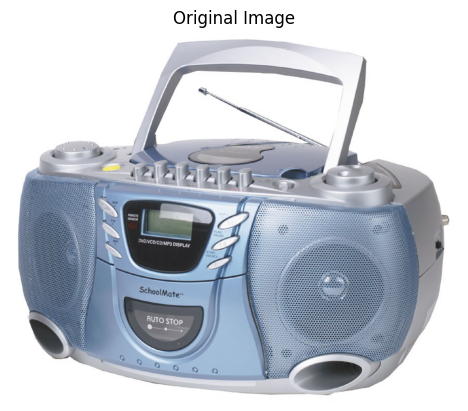

In [11]:
show_tensor_image(full_train_dataset[2000][0], title="Original Image", vmin=0, vmax=255)

## Transformaciones
- Se definen transformaciones para el dataset de train y de validation por separado. Dado que en validation no se precisa la parte de Data Augmentation.
-



In [12]:
image_size=224

train_transforms = T.Compose([
    # Redimensionar
    T.Resize((256, 256)),

    # Random crop
    T.RandomCrop((image_size, image_size)),

    # Random horizontal flip
    T.RandomHorizontalFlip(p=0.5),

    # Random rotation
    T.RandomRotation(degrees=15),

    # Cambios aleatorios al brillo, contraste, saturación y tono
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),

    # Random perspective
    T.RandomPerspective(distortion_scale=0.2, p=0.3),

    # Convertir a tensor (uint8)
    T.ToImage(),

    # Convertir a float y escalar a [0, 1]
    T.ToDtype(torch.float32, scale=True),

    # Normalizar
    T.Normalize(mean=[0.485, 0.456, 0.406],  # Valores estándar para ImageNet para los canales R,G,B
                std=[0.229, 0.224, 0.225])
])

# Validation transforms
val_transforms = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True), # Añadir conversión a float aquí también
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

In [13]:
# Train dataset con data augmentation
train_dataset = Imagenette(
    root=data_dir,
    split='train',
    size='full',
    download=False,  # Already downloaded
    transform=train_transforms
)

# Validation dataset sin data augmentation
val_dataset = Imagenette(
    root=data_dir,
    split='val',
    size='full',
    download=False,  # Already downloaded
    transform=val_transforms
)

In [14]:
print(f"Training dataset: {len(train_dataset)} registros")
print(f"Validation dataset: {len(val_dataset)} registros")


Training dataset: 9469 registros
Validation dataset: 3925 registros


In [15]:
from collections import Counter
def analyze_dataset_balance(dataset, class_names):
    """
    Analiza la distribución de clases en el dataset.

    Args:
        dataset: dataset de PyTorch
        class_names: Lista de nombres de clases

    Returns:
        dict: Distribución de clases
    """
    print("Analizando la distribución de clases del dataset...")

    # Recolecta todas las etiquetas
    labels = []
    for _, label in dataset:
        labels.append(label)

    # Cuenta las ocurrencias
    class_counts = Counter(labels)

    # Imprime la distribución
    print("\nDistribución de Clases:")
    print("-" * 40)
    for i, (class_idx, count) in enumerate(sorted(class_counts.items())):
        class_name = class_names[class_idx] if class_idx < len(class_names) else f"Clase {class_idx}"
        percentage = (count / len(dataset)) * 100
        print(f"{class_name}: {count} muestras ({percentage:.1f}%)")

    # Calcula métricas de balance
    counts = list(class_counts.values())
    min_count = min(counts)
    max_count = max(counts)
    balance_ratio = min_count / max_count

    print(f"\nAnálisis de Balance:")
    print(f"Clase más frecuente: {max_count} muestras")
    print(f"Clase menos frecuente: {min_count} muestras")
    print(f"Relación de balance: {balance_ratio:.3f} (1.0 = perfectamente balanceado)")

    if balance_ratio < 0.5:
        print("⚠️  ¡El dataset está desbalanceado! Considera usar pesos de clase o estrategias de muestreo.")
    elif balance_ratio < 0.8:
        print("⚠️  El dataset tiene un desbalance moderado.")
    else:
        print("✅ El dataset está razonablemente balanceado.")

    return dict(class_counts)

In [16]:
class_counts = analyze_dataset_balance(full_train_dataset, full_train_dataset.classes)

Analizando la distribución de clases del dataset...

Distribución de Clases:
----------------------------------------
('tench', 'Tinca tinca'): 963 muestras (10.2%)
('English springer', 'English springer spaniel'): 955 muestras (10.1%)
('cassette player',): 993 muestras (10.5%)
('chain saw', 'chainsaw'): 858 muestras (9.1%)
('church', 'church building'): 941 muestras (9.9%)
('French horn', 'horn'): 956 muestras (10.1%)
('garbage truck', 'dustcart'): 961 muestras (10.1%)
('gas pump', 'gasoline pump', 'petrol pump', 'island dispenser'): 931 muestras (9.8%)
('golf ball',): 951 muestras (10.0%)
('parachute', 'chute'): 960 muestras (10.1%)

Análisis de Balance:
Clase más frecuente: 993 muestras
Clase menos frecuente: 858 muestras
Relación de balance: 0.864 (1.0 = perfectamente balanceado)
✅ El dataset está razonablemente balanceado.


## Crear DataLoaders

In [17]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Dataset balanceado, shuffle normal es suficiente
    num_workers=NUM_WORKERS,
    pin_memory=True if DEVICE != 'cpu' else False,
    drop_last=True  # Importante para BatchNorm
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if DEVICE != 'cpu' else False
)

## DenseNet

Paper original de [DenseNet](https://arxiv.org/pdf/1608.06993).

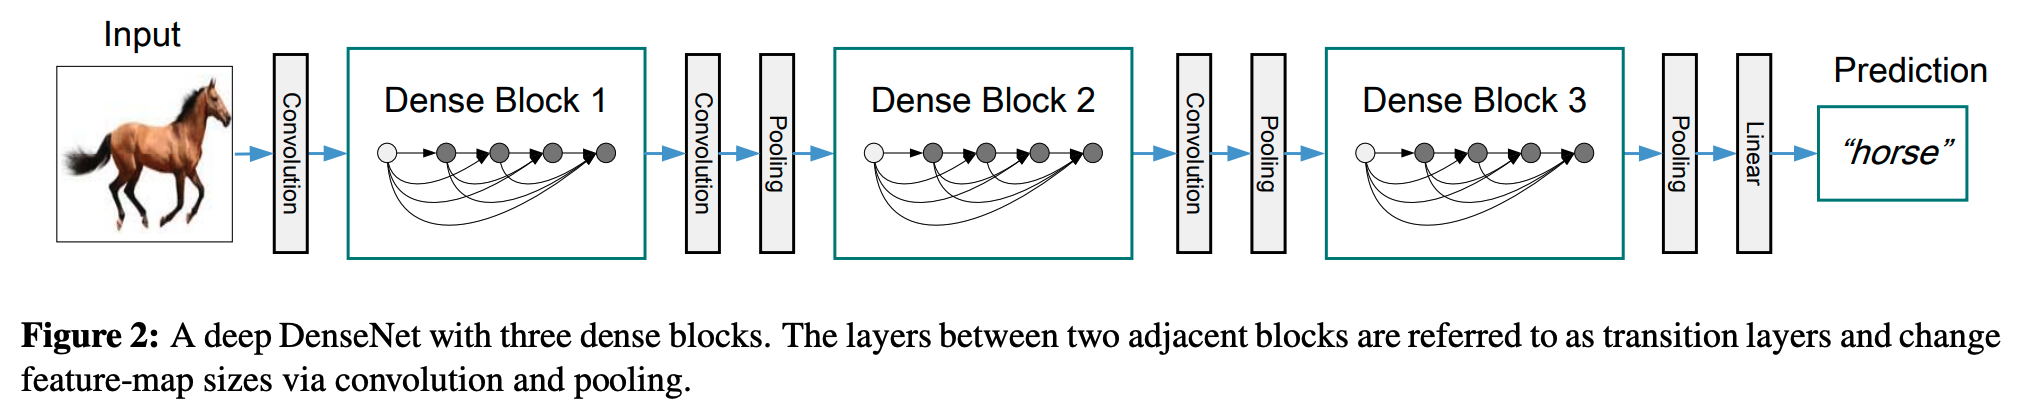

In [18]:
class DenseBlock(nn.Module):
    """
    Dense Block para DenseNet.
    """
    def __init__(self, in_channels, growth_rate, num_layers):
        super(DenseBlock, self).__init__()

        layers = []
        for i in range(num_layers):
            layers.append(self._make_dense_layer(in_channels + i * growth_rate, growth_rate))

        self.layers = nn.ModuleList(layers)
        self.num_layers = num_layers

    def _make_dense_layer(self, in_channels, growth_rate):
        return nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1, bias=False),
            nn.BatchNorm2d(4 * growth_rate),
            nn.ReLU(inplace=True),
            nn.Conv2d(4 * growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)
        )

    def forward(self, x):
        features = [x]
        for layer in self.layers:
            new_feature = layer(torch.cat(features, 1))
            features.append(new_feature)
        return torch.cat(features, 1)

class TransitionLayer(nn.Module):
    """
    Transition Layer para DenseNet.
    """
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.bn(x)
        x = self.relu(x)
        x = self.conv(x)
        x = self.pool(x)
        return x

class DenseNet(nn.Module):
    """
    DenseNet implementación desde cero.
    """
    def __init__(self, num_classes=10, growth_rate=32, block_config=(6, 12, 24, 16),
                 num_init_features=64, drop_rate=0.0):
        super(DenseNet, self).__init__()

        # Initial convolution
        self.features = nn.Sequential(
            nn.Conv2d(3, num_init_features, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(num_init_features),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Dense blocks
        num_features = num_init_features
        for i, num_layers in enumerate(block_config):
            block = DenseBlock(num_features, growth_rate, num_layers)
            self.features.add_module(f'denseblock{i+1}', block)
            num_features = num_features + num_layers * growth_rate

            if i != len(block_config) - 1:
                trans = TransitionLayer(num_features, num_features // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_features = num_features // 2

        # Final batch norm
        self.features.add_module('norm5', nn.BatchNorm2d(num_features))

        # Classifier
        self.classifier = nn.Linear(num_features, num_classes)

        # Dropout
        self.drop_rate = drop_rate

    def forward(self, x):
        features = self.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        if self.drop_rate > 0:
            out = F.dropout(out, p=self.drop_rate, training=self.training)
        out = self.classifier(out)
        return out

### Crear el modelo DenseNet

In [19]:
# DenseNet-121 (configuración estándar)
model = DenseNet(
    num_classes=10,           # 10 clases de Imagenette
    growth_rate=32,          # Growth rate estándar
    block_config=(6, 12, 24, 16),  # DenseNet-121
    num_init_features=64,    # Features iniciales
    drop_rate=0.2            # Dropout para regularización
)

# Mover modelo al dispositivo
model = model.to(DEVICE)

In [20]:
summary(model, input_size=(1, 3, 224, 224), device=DEVICE)


Layer (type:depth-idx)                        Output Shape              Param #
DenseNet                                      [1, 10]                   --
├─Sequential: 1-1                             [1, 1024, 7, 7]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─DenseBlock: 2-5                        [1, 256, 56, 56]          --
│    │    └─ModuleList: 3-1                   --                        335,040
│    └─TransitionLayer: 2-6                   [1, 128, 28, 28]          --
│    │    └─BatchNorm2d: 3-2                  [1, 256, 56, 56]          512
│    │    └─ReLU: 3-3                         [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-4                       [1, 128, 56, 56]          32,768
│    │

#### Definir la función de pérdida y optimizador

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)


In [22]:
def train_with_logging(model, optimizer, criterion, train_loader, val_loader,
                      device, epochs=10, log_every=1):
    """
    Entrenar modelo con logging detallado.
    """
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()

        # Validation
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                total_val += target.size(0)
                correct_val += (predicted == target).sum().item()

        # Calcular métricas
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_acc = 100. * correct_train / total_train
        val_acc = 100. * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Logging
        if epoch % log_every == 0:
            print(f'Epoch {epoch+1:3d}/{epochs}: '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses



In [23]:
# Entrenar el modelo
# ======================

print("Iniciando entrenamiento...")
print("=" * 60)

EPOCHS = 20

train_losses, val_losses = train_with_logging(
    model, optimizer, criterion, train_loader, val_loader,
    DEVICE, epochs=EPOCHS, log_every=1
)

Iniciando entrenamiento...
Epoch   1/20: Train Loss: 1.9708, Train Acc: 30.74% | Val Loss: 2.0940, Val Acc: 29.10%
Epoch   2/20: Train Loss: 1.7105, Train Acc: 40.68% | Val Loss: 1.6550, Val Acc: 44.51%
Epoch   3/20: Train Loss: 1.4678, Train Acc: 50.25% | Val Loss: 1.2824, Val Acc: 58.11%
Epoch   4/20: Train Loss: 1.3068, Train Acc: 56.39% | Val Loss: 1.1300, Val Acc: 63.72%
Epoch   5/20: Train Loss: 1.1865, Train Acc: 60.95% | Val Loss: 1.1460, Val Acc: 63.29%
Epoch   6/20: Train Loss: 1.0722, Train Acc: 64.58% | Val Loss: 0.9521, Val Acc: 69.43%
Epoch   7/20: Train Loss: 0.9951, Train Acc: 67.71% | Val Loss: 0.9082, Val Acc: 71.36%
Epoch   8/20: Train Loss: 0.9382, Train Acc: 69.64% | Val Loss: 0.8916, Val Acc: 71.92%
Epoch   9/20: Train Loss: 0.8781, Train Acc: 71.14% | Val Loss: 0.7846, Val Acc: 74.42%
Epoch  10/20: Train Loss: 0.8417, Train Acc: 72.73% | Val Loss: 0.9385, Val Acc: 70.04%
Epoch  11/20: Train Loss: 0.8017, Train Acc: 73.74% | Val Loss: 0.8457, Val Acc: 73.40%
Epoch

In [25]:
### Paro porque veo que empieza a haber overfitting

In [24]:
# Entrenar el modelo
print("Iniciando entrenamiento...")
print("=" * 60)

EPOCHS = 50

train_losses, val_losses = train_with_logging(
    model, optimizer, criterion, train_loader, val_loader,
    DEVICE, epochs=EPOCHS, log_every=1
)

Iniciando entrenamiento...
Epoch   1/50: Train Loss: 0.5587, Train Acc: 81.60% | Val Loss: 0.5607, Val Acc: 82.04%
Epoch   2/50: Train Loss: 0.5343, Train Acc: 82.76% | Val Loss: 0.5606, Val Acc: 82.45%
Epoch   3/50: Train Loss: 0.4966, Train Acc: 83.73% | Val Loss: 0.5409, Val Acc: 83.26%
Epoch   4/50: Train Loss: 0.5017, Train Acc: 83.61% | Val Loss: 0.5500, Val Acc: 82.37%
Epoch   5/50: Train Loss: 0.4878, Train Acc: 83.98% | Val Loss: 0.5068, Val Acc: 83.95%
Epoch   6/50: Train Loss: 0.4651, Train Acc: 84.82% | Val Loss: 0.4861, Val Acc: 84.31%
Epoch   7/50: Train Loss: 0.4598, Train Acc: 84.75% | Val Loss: 0.4583, Val Acc: 85.55%
Epoch   8/50: Train Loss: 0.4421, Train Acc: 85.49% | Val Loss: 0.5246, Val Acc: 83.54%


KeyboardInterrupt: 

In [31]:
class EarlyStopping:
    def __init__(self, patience=5):
        """
        Args:
            patience (int): Cuántas épocas esperar después de la última mejora.
        """
        self.patience = patience
        self.counter = 0
        self.best_score = float("inf")
        self.val_loss_min = float("inf")
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss > self.best_score:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0



In [32]:
def print_log(epoch, train_loss, val_loss):
    print(
        f"Epoch: {epoch + 1:03d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}"
    )

In [34]:
def evaluate(model, criterion, data_loader, device):
    """
    Evalúa el modelo en los datos proporcionados y calcula la pérdida promedio.

    Args:
        model (torch.nn.Module): El modelo que se va a evaluar.
        criterion (torch.nn.Module): La función de pérdida que se utilizará para calcular la pérdida.
        data_loader (torch.utils.data.DataLoader): DataLoader que proporciona los datos de evaluación.

    Returns:
        float: La pérdida promedio en el conjunto de datos de evaluación.

    """
    model.eval()  # ponemos el modelo en modo de evaluacion
    total_loss = 0  # acumulador de la perdida
    with torch.no_grad():  # deshabilitamos el calculo de gradientes
        for x, y in data_loader:  # iteramos sobre el dataloader
            x = x.to(device)  # movemos los datos al dispositivo
            y = y.to(device)  # movemos los datos al dispositivo
            output = model(x)  # forward pass
            total_loss += criterion(output, y).item()  # acumulamos la perdida
    return total_loss / len(data_loader)  # retornamos la perdida promedio



In [35]:
import copy
import torch

def train(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    device,
    do_early_stopping=True,
    patience=5,
    epochs=10,
    log_fn=print_log,
    log_every=1,
    restore_best_weights=True,
    checkpoint_path=None,  # e.g., "best_densenet.pt"
):
    """
    Entrena el modelo utilizando el optimizador y la función de pérdida proporcionados.
    Usa EarlyStopping (simple) basado en val_loss y restaura el mejor estado si se desea.

    Returns:
        Tuple[List[float], List[float]]: (errores de train por época, errores de validación por época)
    """
    epoch_train_errors = []
    epoch_val_errors = []

    # Early stopping (opcional)
    if do_early_stopping:
        early_stopping = EarlyStopping(patience=patience)

    # Guardamos el mejor estado (para restore_best_weights)
    best_state = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    best_epoch = -1

    for epoch in range(epochs):
        # ---------- Entrenamiento ----------
        model.train()
        train_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad() # Se resetea los gradientes
            output = model(x) # forward pass (prediccion)
            batch_loss = criterion(output, y) # se calcula la perdida con la salida esperada
            batch_loss.backward() # backpropagation
            optimizer.step() # se actualiza los pesos

            train_loss += batch_loss.item() # se acumula la perdida

        train_loss /= len(train_loader) # se calcula la perdida promedio de la epoch
        epoch_train_errors.append(train_loss) # se guarda la perdida de entrenamiento

        # ---------- Validación ----------
        # model.eval()
        # with torch.no_grad():
        val_loss = evaluate(model, criterion, val_loader, device)
        epoch_val_errors.append(val_loss)

        # ---------- Mejor modelo hasta ahora ----------
        if val_loss < best_val:
            best_val = val_loss
            best_epoch = epoch
            if restore_best_weights:
                best_state = copy.deepcopy(model.state_dict())
            if checkpoint_path is not None:
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": best_val,
                }, checkpoint_path)

        # ---------- Early Stopping ----------
        if do_early_stopping:
            early_stopping(val_loss)
            if early_stopping.early_stop:
                if restore_best_weights:
                    model.load_state_dict(best_state)
                print(
                    f"Detener entrenamiento en la época {epoch+1:03d}. "
                    f"Mejor val_loss: {best_val:.5f} (época {best_epoch+1:03d})"
                )
                break

        # ---------- Logging ----------
        if log_fn is not None and ((epoch + 1) % log_every == 0):
            log_fn(epoch, train_loss, val_loss)

    # Si no se detuvo anticipadamente, restauramos el mejor (opcional)
    if restore_best_weights and not (do_early_stopping and early_stopping.early_stop):
        model.load_state_dict(best_state)

    return epoch_train_errors, epoch_val_errors


In [36]:
EPOCHS = 50

# Instancia del modelo
model = DenseNet(num_classes=10, growth_rate=32, block_config=(6, 12, 24, 16), drop_rate=0.0).to(DEVICE)

# Optimizador y loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

In [37]:
epoch_train_errors, epoch_val_errors = train(
    model, optimizer, criterion, train_loader, val_loader, DEVICE,
    do_early_stopping=True, patience=10, epochs=100, log_fn=print_log, log_every=1,
    restore_best_weights=True, checkpoint_path="best_densenet.pt"
)

Epoch: 001 | Train Loss: 1.98384 | Val Loss: 1.82813
Epoch: 002 | Train Loss: 1.77067 | Val Loss: 1.57031
Epoch: 003 | Train Loss: 1.54510 | Val Loss: 1.52505
Epoch: 004 | Train Loss: 1.35858 | Val Loss: 1.41698
Epoch: 005 | Train Loss: 1.21810 | Val Loss: 1.12598
Epoch: 006 | Train Loss: 1.11837 | Val Loss: 1.03778
Epoch: 007 | Train Loss: 1.01153 | Val Loss: 1.08322
Epoch: 008 | Train Loss: 0.94014 | Val Loss: 0.94898
Epoch: 009 | Train Loss: 0.88710 | Val Loss: 1.01148
Epoch: 010 | Train Loss: 0.83600 | Val Loss: 0.74651
Epoch: 011 | Train Loss: 0.79910 | Val Loss: 0.75530
Epoch: 012 | Train Loss: 0.75591 | Val Loss: 0.66181
Epoch: 013 | Train Loss: 0.72174 | Val Loss: 0.70140
Epoch: 014 | Train Loss: 0.70236 | Val Loss: 0.70634
Epoch: 015 | Train Loss: 0.66760 | Val Loss: 0.63721
Epoch: 016 | Train Loss: 0.63762 | Val Loss: 0.62166
Epoch: 017 | Train Loss: 0.63771 | Val Loss: 0.76960
Epoch: 018 | Train Loss: 0.59167 | Val Loss: 0.67492
Epoch: 019 | Train Loss: 0.57876 | Val Loss: 0